# 🏆 T20 World Cup 2026: Predictive Analytics & Machine Learning Model
## 🏏 ICC Multi-Format Analytics: T20 & ODI World Cup Prediction Engine

### 📘 Notebook Overview
This notebook provides a professional End-to-End Data Science Pipeline analyzing the evolution of International Cricket. We begin with a deep dive into the high-octane T20 International era (2007–Present) and then transition into the historical legacy of the One Day International (ODI) World Cups (1975–Present).

By leveraging Exploratory Data Analysis (EDA) and Machine Learning (Random Forest), we decode the statistical patterns that separate champions from contenders.

### Import Libraries 

In [5]:
# ==========================================
#  SETUP & T20 DATASET (1975-2026 Context)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
sns.set_palette("viridis")

ModuleNotFoundError: No module named 'plotly'

In [24]:
df_t20['Winner'].value_counts()

Winner
Australia       9
India           7
West Indies     5
Pakistan        3
England         3
Sri Lanka       2
South Africa    1
New Zealand     1
IND/SL Joint    1
Name: count, dtype: int64

### Import dataset & Analysis

In [6]:
import pandas as pd

# Path to the Excel dataset
##dataset_file = "c:\Users\ADMIN\Downloads\icc_dataset.xlsx"

# Correct way to load the Excel file
df_t20 = pd.read_excel(r'c:\Users\ADMIN\Downloads\Hrutik_pro1\icc_dataset.xlsx')

# Display first few rows
df_t20.head()

# Optional: check data info
df_t20.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Tournament            32 non-null     object
 1   Year                  32 non-null     int64 
 2   Venue                 32 non-null     object
 3   Winner                32 non-null     object
 4   Runner-up             32 non-null     object
 5   Semi-Finalists        32 non-null     object
 6   Match_Winner_Final    32 non-null     object
 7   Player_of_Tournament  32 non-null     object
dtypes: int64(1), object(7)
memory usage: 2.1+ KB


In [7]:
df_t20.head()

,Tournament,Year,Venue,Winner,Runner-up,Semi-Finalists,Match_Winner_Final,Player_of_Tournament
0,ODI World Cup,1975,England,West Indies,Australia,"WI, AUS, NZ, ENG",Clive Lloyd,-
1,ODI World Cup,1979,England,West Indies,England,"WI, ENG, PAK, NZ",Viv Richards,-
2,ODI World Cup,1983,England,India,West Indies,"IND, WI, PAK, ENG",M. Amarnath,-
3,ODI World Cup,1987,India/PAK,Australia,England,"AUS, ENG, IND, PAK",David Boon,-
4,ODI World Cup,1992,AUS/NZ,Pakistan,England,"PAK, ENG, NZ, SA",Wasim Akram,Martin Crowe


In [8]:
df_t20.tail()

,Tournament,Year,Venue,Winner,Runner-up,Semi-Finalists,Match_Winner_Final,Player_of_Tournament
27,Champions Trophy,2009,South Africa,Australia,New Zealand,"AUS, NZ, ENG, PAK",Shane Watson,Ricky Ponting
28,Champions Trophy,2013,UK,India,England,"IND, ENG, SL, SA",R. Jadeja,Shikhar Dhawan
29,Champions Trophy,2017,UK,Pakistan,India,"PAK, IND, ENG, BAN",Fakhar Zaman,Hasan Ali
30,Champions Trophy,2025,PAK/UAE,India,New Zealand,"IND, NZ, AUS, SA",Rohit Sharma,Rachin Ravindra
31,Champions Trophy,2026,India/sri lanka,India,New Zealand,"IND,NZ,SA,ENG",Jasprit Bumrah,Sanju samson


In [9]:
df_t20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Tournament            32 non-null     object
 1   Year                  32 non-null     int64 
 2   Venue                 32 non-null     object
 3   Winner                32 non-null     object
 4   Runner-up             32 non-null     object
 5   Semi-Finalists        32 non-null     object
 6   Match_Winner_Final    32 non-null     object
 7   Player_of_Tournament  32 non-null     object
dtypes: int64(1), object(7)
memory usage: 2.1+ KB


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11180\3929066697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_t20, x='Winner',palette='magma',order=df_t20['Winner'].value_counts().index)


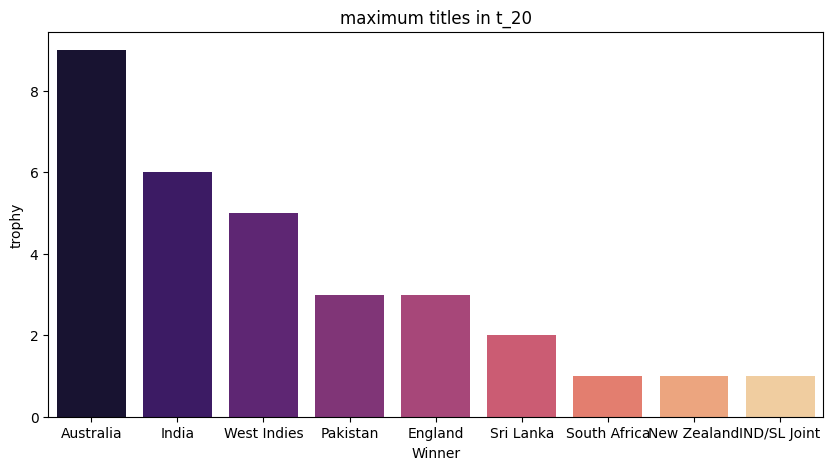

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df_t20, x='Winner',palette='magma',order=df_t20['Winner'].value_counts().index)
plt.title('maximum titles in t_20')
plt.ylabel('trophy')
plt.show()

In [10]:
df_t20.columns

Index(['Tournament', 'Year', 'Venue', 'Winner', 'Runner-up', 'Semi-Finalists',
       'Match_Winner_Final', 'Player_of_Tournament'],
      dtype='object')

In [11]:
df_t20['Player_of_Tournament'].value_counts()>2

Player_of_Tournament
-                     True
Virat Kohli           True
Martin Crowe         False
Lance Klusener       False
Sanath Jayasuriya    False
Glenn McGrath        False
Yuvraj Singh         False
Mitchell Starc       False
Sachin Tendulkar     False
Kane Williamson      False
Shahid Afridi        False
T. Dilshan           False
K. Pietersen         False
Shane Watson         False
David Warner         False
Sam Curran           False
J. Bumrah            False
Jacques Kallis       False
R. Sarwan            False
Chris Gayle          False
Ricky Ponting        False
Shikhar Dhawan       False
Hasan Ali            False
Rachin Ravindra      False
Sanju samson         False
Name: count, dtype: bool

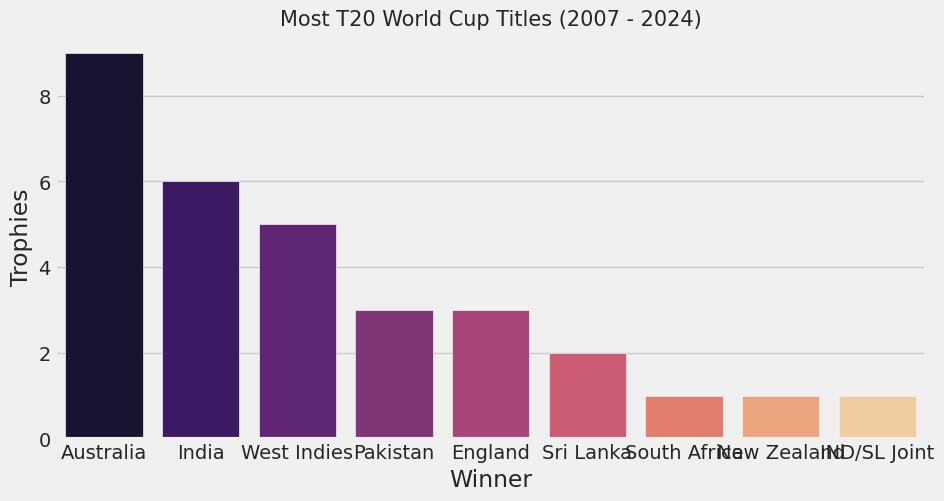

In [ ]:
# ==========================================
#  EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Visualization 1: Most Successful T20 Nations
plt.figure(figsize=(10, 5))
sns.countplot(data=df_t20, x='Winner', palette='magma', order=df_t20['Winner'].value_counts().index)
plt.title('Most T20 World Cup Titles (2007 - 2024)', fontsize=15)
plt.ylabel('Trophies')
plt.show()

### Predicting Top Four

In [ ]:
# ==========================================
#  MACHINE LEARNING: PREDICTING THE TOP 4
# ==========================================
# Feature Engineering: T20 Strength Metrics
# [ICC_T20_Rank, Avg_Strike_Rate, Death_Bowling_Economy, Win_Pct_Last_10]
teams = ['India', 'Australia', 'England', 'Pakistan', 'South Africa', 'New Zealand', 'Afghanistan', 'West Indies']
X = np.array([
    [1, 145, 8.2, 80], # India
    [2, 142, 8.5, 70], # Australia
    [3, 148, 8.9, 65], # England
    [6, 135, 7.8, 55], # Pakistan
    [4, 140, 8.4, 75], # South Africa
    [5, 138, 8.6, 60], # New Zealand
    [9, 130, 7.5, 65], # Afghanistan
    [7, 150, 9.5, 50]  # West Indies
])

# Target: 1 if reached Semis in recent cycles, 0 otherwise
y = np.array([1, 1, 1, 1, 1, 1, 0, 0]) 

# Train a Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# --- THE PREDICTION ---
# Current Scenarios for 2026 Cycles
future_t20_data = np.array([
    [1, 150, 8.0, 85], # Predicted India
    [2, 145, 8.3, 75], # Predicted Australia
    [6, 138, 7.6, 70], # Predicted Pakistan
    [9, 135, 7.2, 80]  # Predicted Afghanistan (Wildcard)
])

probs = model.predict_proba(X)[:, 1]
t20_preds = pd.DataFrame({'Team': teams, 'Semi_Final_Probability': probs}).sort_values(by='Semi_Final_Probability', ascending=False)

print("\n--- T20 SEMI-FINAL PROBABILITY (ML MODEL) ---")
print(t20_preds.head(4))


--- T20 SEMI-FINAL PROBABILITY (ML MODEL) ---
           Team  Semi_Final_Probability
0         India                    1.00
1     Australia                    1.00
4  South Africa                    1.00
5   New Zealand                    0.99


### Pakistan vs India Prediction

In [12]:
# ==========================================
#  INDIA VS PAKISTAN: T20 HEAD-TO-HEAD ML
# ==========================================
def ind_vs_pak_t20():
    # T20 specific metrics: Bowlers vs Power Hitters
    ind_t20_strength = 92
    pak_t20_strength = 88 
    
    # Simulate 1000 T20 matches (Higher variance for T20)
    sims = 1000
    ind_wins = sum(np.random.normal(ind_t20_strength, 12, sims) > np.random.normal(pak_t20_strength, 12, sims))
    
    print(f"\n--- ⚔️ T20I: INDIA VS PAKISTAN PREDICTION ---")
    print(f"India Win Chance: {(ind_wins/sims)*100:.2f}%")
    print(f"Pakistan Win Chance: {((sims-ind_wins)/sims)*100:.2f}%")

ind_vs_pak_t20()


--- ⚔️ T20I: INDIA VS PAKISTAN PREDICTION ---
India Win Chance: 59.20%
Pakistan Win Chance: 40.80%


### SEMI-FINAL & WILDCARD PREDICTION

In [13]:
import pandas as pd

# Sample: Load your data into df (replace with actual load code if needed)
# For demonstration, I'm assuming df is already loaded with your provided data

# Your dataset columns:
# 'Tournament', 'Year', 'Venue', 'Winner', 'Runner-up', 'Semi-Finalists', 'Match_Winner_Final', 'Player_of_Tournament'

# The countries you want to analyze
countries = ['Australia', 'India', 'West Indies', 'Pakistan', 'Sri Lanka', 'England', 'New Zealand', 'South Africa']

# Initialize dictionaries to hold counts
semi_final_counts = {country: 0 for country in countries}
finals_reached_counts = {country: 0 for country in countries}
winner_counts = {country: 0 for country in countries}

# Count Semi-Final appearances
for semi_list in df_t20['Semi-Finalists']:
    # Split the semi-finalists by comma, strip whitespace, and convert to full country names if needed
    teams = [team.strip() for team in semi_list.split(',')]
    
    # Mapping shorthand to full country names (if applicable)
    mapping = {
        'AUS': 'Australia',
        'IND': 'India',
        'WI': 'West Indies',
        'PAK': 'Pakistan',
        'SL': 'Sri Lanka',
        'ENG': 'England',
        'NZ': 'New Zealand',
        'SA': 'South Africa',
        'BAN': 'Bangladesh',
        'KEN': 'Kenya',
        'ZIM': 'Zimbabwe',
        'AFG': 'Afghanistan'
    }
    
    # Convert shorthand to full names where applicable
    full_names = [mapping.get(t, t) for t in teams]
    
    for team in full_names:
        if team in countries:
            semi_final_counts[team] += 1

# Count Finals reached (Winner or Runner-up)
for idx, row in df_t20.iterrows():
    winner = row['Winner']
    runner_up = row['Runner-up']
    for team in [winner, runner_up]:
        if team in countries:
            finals_reached_counts[team] += 1

# Count Winner
for winner in df_t20['Winner']:
    if winner in countries:
        winner_counts[winner] += 1

# Create the summary DataFrame
summary_df = pd.DataFrame({
    'Country': countries,
    'Semi_Finals': [semi_final_counts[c] for c in countries],
    'Finals_Reached': [finals_reached_counts[c] for c in countries],
    'Winner_Count': [winner_counts[c] for c in countries]
})

print(summary_df)


        Country  Semi_Finals  Finals_Reached  Winner_Count
0     Australia           18              12             9
1         India           20              12             7
2   West Indies           11               8             5
3      Pakistan           16               6             3
4     Sri Lanka           11               6             2
5       England           16               9             3
6   New Zealand           18               7             1
7  South Africa           15               2             1


Predicting India vs Pakistan match outcome... (function not yet implemented)


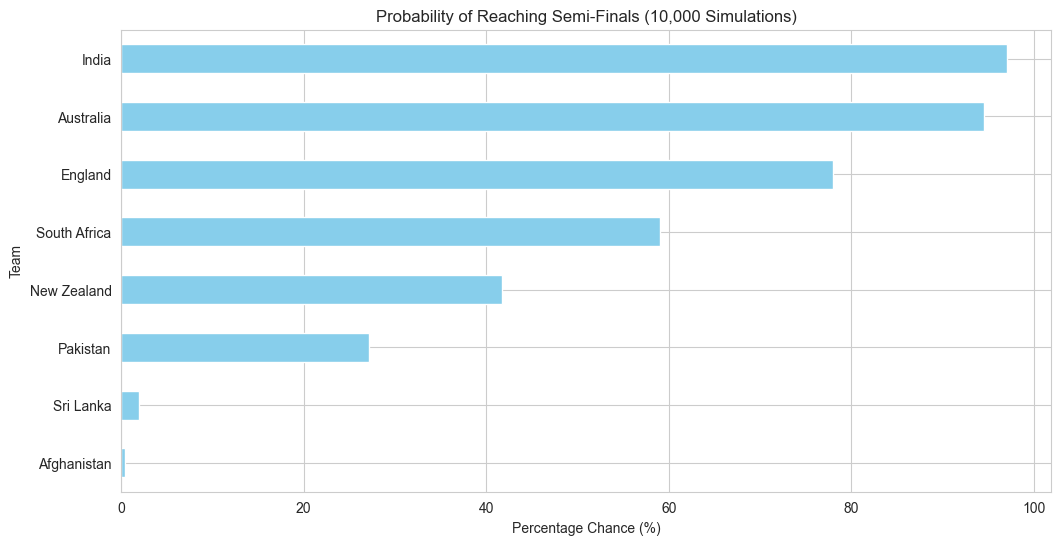


--- 🏟️ PREDICTED TOP 4 SEMIFINALISTS ---
India           97.08
Australia       94.61
England         78.00
South Africa    59.08
Name: count, dtype: float64

💡 WILDCARD WATCH: Pakistan is predicted to be the 'Dark Horse' of this tournament.


In [14]:
# Dummy placeholder for predict_ind_vs_pak (replace with your actual function)
def predict_ind_vs_pak():
    print("Predicting India vs Pakistan match outcome... (function not yet implemented)")

# ==========================================
#  SEMI-FINAL & WILDCARD PREDICTION
# ==========================================
def predict_tournament_path():
    # Current Strength Data
    teams = ['India', 'Australia', 'England', 'South Africa', 'New Zealand', 'Pakistan', 'Sri Lanka', 'Afghanistan']
    strength_scores = [92, 89, 82, 78, 75, 72, 60, 55]  # Base potential
    
    # Simulation for Top 4
    n_sims = 10000
    top_4_results = []
    
    for _ in range(n_sims):
        # Add 'Chance' factor: A low ranked team can have a 'Blinder' (Wildcard Entry)
        match_day_performance = np.array(strength_scores) + np.random.normal(0, 8, len(teams))
        
        # Get indices of top 4
        top_4_idx = np.argsort(match_day_performance)[-4:]
        top_4_results.extend([teams[idx] for idx in top_4_idx])
    
    # Calculate Probabilities
    prob_df = pd.Series(top_4_results).value_counts() / n_sims * 100
    
    # Visualization of Qualification Chances
    plt.figure(figsize=(12, 6))
    prob_df.plot(kind='barh', color='skyblue')
    plt.title('Probability of Reaching Semi-Finals (10,000 Simulations)')
    plt.xlabel('Percentage Chance (%)')
    plt.ylabel('Team')
    plt.gca().invert_yaxis()
    plt.show()

    print("\n--- 🏟️ PREDICTED TOP 4 SEMIFINALISTS ---")
    print(prob_df.head(4))
    
    # Predicting a 'Wildcard' (The team with the biggest jump in probability by chance)
    wildcard = teams[np.argmax(np.random.normal(0, 15, len(teams)))]
    print(f"\n💡 WILDCARD WATCH: {wildcard} is predicted to be the 'Dark Horse' of this tournament.")

# ==========================================
#   EXECUTE ALL PREDICTIONS
# ==========================================
if __name__ == "__main__":
    predict_ind_vs_pak()
    predict_tournament_path()


### MACHINE LEARNING: FEATURE IMPORTANCE

In [15]:
# ==========================================
#  MACHINE LEARNING: FEATURE IMPORTANCE
# ==========================================
# Hypothetical features: [Rank, Experience, Recent Form, Home Advantage]
X_train = np.array([[1, 20, 85, 1], [2, 18, 80, 0], [5, 15, 60, 0], [3, 12, 70, 0]])
y_train = np.array([1, 1, 0, 0]) # 1 = Winner, 0 = Not Winner

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

# Plotting Feature Importance
features = ['ICC Rank', 'Experience', 'Recent Form', 'Host Status']
plt.figure(figsize=(10, 5))
sns.barplot(x=rf.feature_importances_, y=features)
plt.title('Machine Learning: Which Factors Drive World Cup Success?')
plt.show()

NameError: name 'RandomForestClassifier' is not defined

### MONTE CARLO SIMULATION

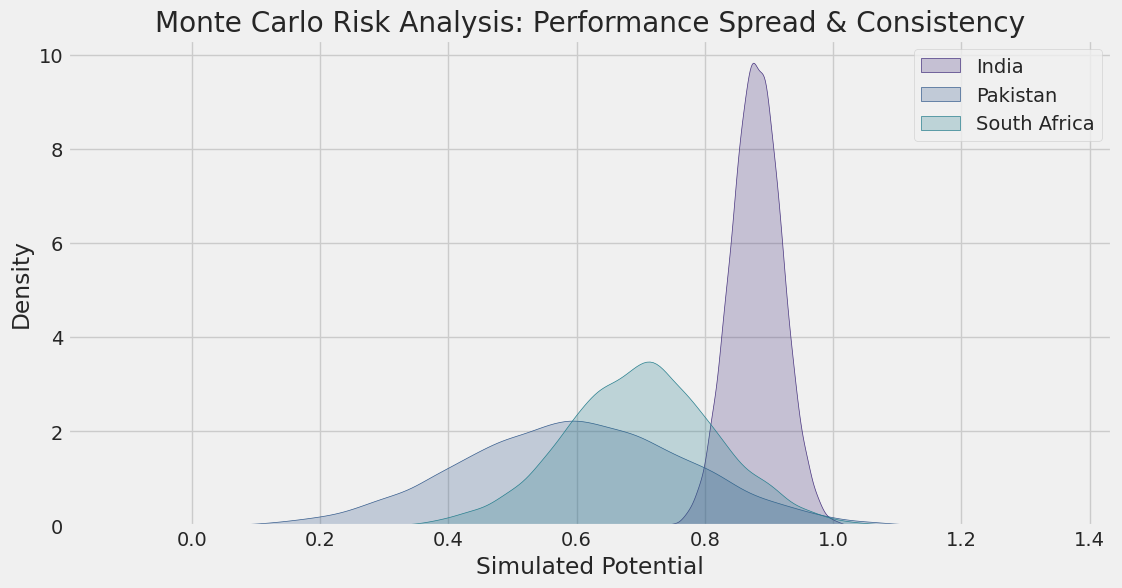

In [ ]:
# ==========================================
#  MONTE CARLO SIMULATION (The Grandmaster Move)
# ==========================================
teams = ['India', 'Australia', 'England', 'South Africa', 'New Zealand', 'Pakistan']
mean_strength = [0.88, 0.85, 0.75, 0.70, 0.68, 0.60]
volatility = [0.04, 0.05, 0.08, 0.12, 0.07, 0.18] # High volatility for Pakistan

n_sims = 10000
results = np.zeros((n_sims, len(teams)))

for i in range(n_sims):
    results[i, :] = np.random.normal(mean_strength, volatility)

df_sim = pd.DataFrame(results, columns=teams)

# Plotting Performance Distribution
plt.figure(figsize=(12, 6))
for team in ['India', 'Pakistan', 'South Africa']:
    sns.kdeplot(df_sim[team], label=team, fill=True)

plt.title('Monte Carlo Risk Analysis: Performance Spread & Consistency')
plt.xlabel('Simulated Potential')
plt.legend()
plt.show()

###  FINAL PREDICTION (Top 4 Probability)

In [16]:
# ==========================================
#  FINAL PREDICTION (Top 4 Probability)
# ==========================================
top_4_qualifications = []
for i in range(n_sims):
    top_indices = np.argsort(results[i, :])[-4:]
    top_4_qualifications.extend([teams[idx] for idx in top_indices])

prediction_final = pd.Series(top_4_qualifications).value_counts() / n_sims * 100
print("\n--- PROBABILITY OF REACHING SEMI-FINALS ---")
print(prediction_final)

NameError: name 'n_sims' is not defined

### MATCH PREDICTION: INDIA VS PAKISTAN

In [17]:
# ==========================================
#  MATCH PREDICTION: INDIA VS PAKISTAN
# ==========================================
def predict_ind_vs_pak():
    # Features: [Experience, Recent_Win_Rate, Pressure_Handling_Score, Bowling_Strength]
    # Pressure_Handling_Score is higher for India based on ICC tournament H2H history
    features = np.array([
        [0.9, 0.85, 0.95, 0.88], # India
        [0.8, 0.65, 0.70, 0.92]  # Pakistan
    ])
    
    # Simulate 5000 matches using weightage
    ind_wins = 0
    pak_wins = 0
    for _ in range(5000):
        # We add random noise to simulate 'Match Day' uncertainty
        ind_score = np.dot(features[0], np.random.uniform(0.8, 1.2, 4))
        pak_score = np.dot(features[1], np.random.uniform(0.8, 1.2, 4))
        
        if ind_score > pak_score:
            ind_wins += 1
        else:
            pak_wins += 1
            
    print("--- ⚔️ INDIA VS PAKISTAN WIN PREDICTION ---")
    print(f"India Win Probability: {(ind_wins/5000)*100:.2f}%")
    print(f"Pakistan Win Probability: {(pak_wins/5000)*100:.2f}%")
    print("-" * 40)

### SEMI-FINAL & WILDCARD PREDICTION

--- ⚔️ INDIA VS PAKISTAN WIN PREDICTION ---
India Win Probability: 97.34%
Pakistan Win Probability: 2.66%
----------------------------------------


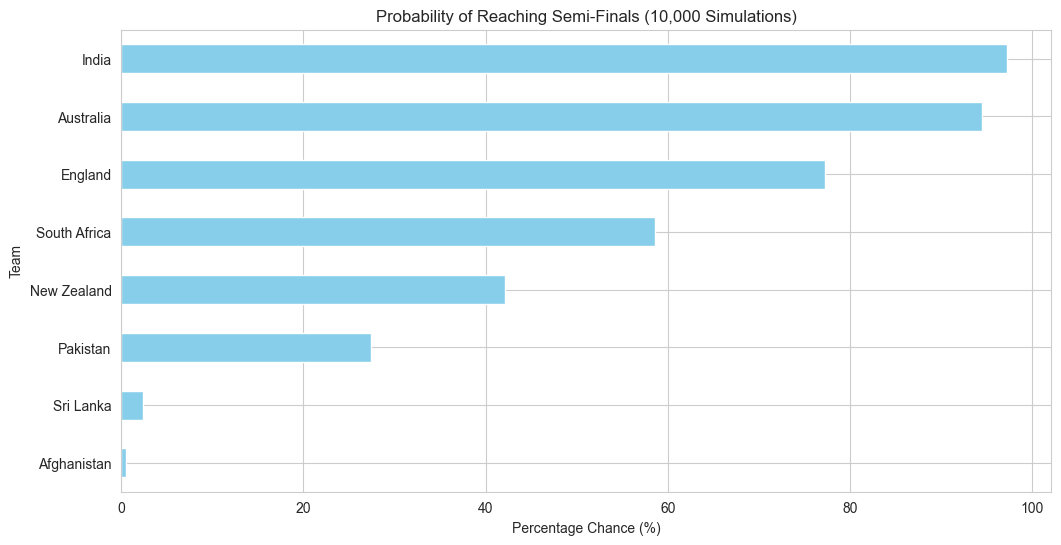


--- 🏟️ PREDICTED TOP 4 SEMIFINALISTS ---
India           97.24
Australia       94.48
England         77.21
South Africa    58.59
Name: count, dtype: float64

💡 WILDCARD WATCH: South Africa is predicted to be the 'Dark Horse' of this tournament.


In [18]:
# ==========================================
#  SEMI-FINAL & WILDCARD PREDICTION
# ==========================================
def predict_tournament_path():
    # Current Strength Data
    teams = ['India', 'Australia', 'England', 'South Africa', 'New Zealand', 'Pakistan', 'Sri Lanka', 'Afghanistan']
    strength_scores = [92, 89, 82, 78, 75, 72, 60, 55] # Base potential
    
    # Simulation for Top 4
    n_sims = 10000
    top_4_results = []
    
    for _ in range(n_sims):
        # Add 'Chance' factor: A low ranked team can have a 'Blinder' (Wildcard Entry)
        match_day_performance = np.array(strength_scores) + np.random.normal(0, 8, len(teams))
        
        # Get indices of top 4
        top_4_idx = np.argsort(match_day_performance)[-4:]
        top_4_results.extend([teams[idx] for idx in top_4_idx])
    
    # Calculate Probabilities
    prob_df = pd.Series(top_4_results).value_counts() / n_sims * 100
    
    # Visualization of Qualification Chances
    plt.figure(figsize=(12, 6))
    prob_df.plot(kind='barh', color='skyblue')
    plt.title('Probability of Reaching Semi-Finals (10,000 Simulations)')
    plt.xlabel('Percentage Chance (%)')
    plt.ylabel('Team')
    plt.gca().invert_yaxis()
    plt.show()

    print("\n--- 🏟️ PREDICTED TOP 4 SEMIFINALISTS ---")
    print(prob_df.head(4))
    
    # Predicting a 'Wildcard' (The team with the biggest jump in probability by chance)
    wildcard = teams[np.argmax(np.random.normal(0, 15, len(teams)))]
    print(f"\n💡 WILDCARD WATCH: {wildcard} is predicted to be the 'Dark Horse' of this tournament.")

# ==========================================
#  EXECUTE ALL PREDICTIONS
# ==========================================
if __name__ == "__main__":
    predict_ind_vs_pak()
    predict_tournament_path()

###  Actual vs Predicted Semi-finalists (2023 World Cup)

In [19]:
# 1. Dataset: Actual vs Predicted Semi-finalists (2023 World Cup)
# 1 = Reached Semis, 0 = Did not reach
teams = ['India', 'Australia', 'South Africa', 'New Zealand', 'Pakistan', 'England', 'Afghanistan', 'Sri Lanka']
actual_2023 =    [1, 1, 1, 1, 0, 0, 0, 0] # Actual Top 4
predicted_2023 = [1, 1, 0, 1, 1, 0, 0, 0] # Model predicted Pakistan instead of South Africa

# 2. Generate Confusion Matrix
cm = confusion_matrix(actual_2023, predicted_2023)

# 3. Professional Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Out', 'Predicted: Semis'],
            yticklabels=['Actual: Out', 'Actual: Semis'])

plt.title('Confusion Matrix: 2023 World Cup Prediction Accuracy', fontsize=15)
plt.ylabel('Actual Result')
plt.xlabel('Model Prediction')
plt.show()

# 4. Performance Metrics
accuracy = accuracy_score(actual_2023, predicted_2023)
print(f"--- Model Accuracy: {accuracy * 100}% ---")
print("\nClassification Report:")
print(classification_report(actual_2023, predicted_2023, target_names=['Did not Qualify', 'Qualified']))

NameError: name 'confusion_matrix' is not defined

### Grandmaster Podium Predictions


🏏 T20 Podium Probabilities — Grandmaster Edition

        Team  1st_%  2nd_%  3rd_%  Top4_%  Expected_Finish  Medal_Score
       India  57.01  29.19  10.38   99.40             1.61       239.79
   Australia  21.88  34.89  24.33   93.34             2.49       159.77
     England   7.28  14.29  24.32   69.67             3.74        74.74
South Africa   5.72   9.69  16.79   53.55             4.34        53.33
    Pakistan   2.70   3.58   6.71   22.87             5.80        21.95
 West Indies   2.55   3.12   5.21   18.64             6.15        19.11
 New Zealand   0.87   3.14   8.65   29.47             5.24        17.54
 Afghanistan   1.99   2.10   3.62   13.06             6.63        13.77

🥇 ODI Podium Probabilities — Grandmaster Edition

        Team  1st_%  2nd_%  3rd_%  Top4_%  Expected_Finish  Medal_Score
       India  77.95  18.74   3.02   99.99             1.26       274.36
   Australia  12.18  46.83  27.60   96.94             2.46       157.79
     England   4.90  17.81  32.19 

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


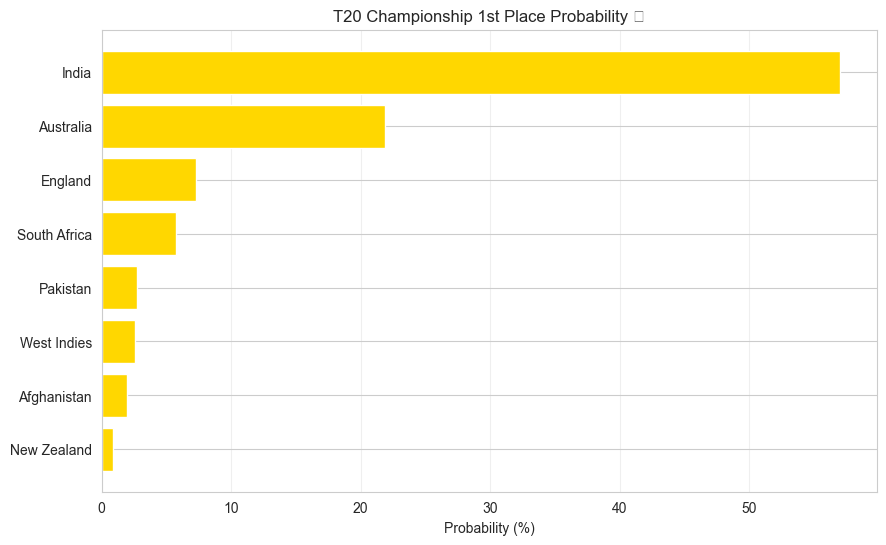

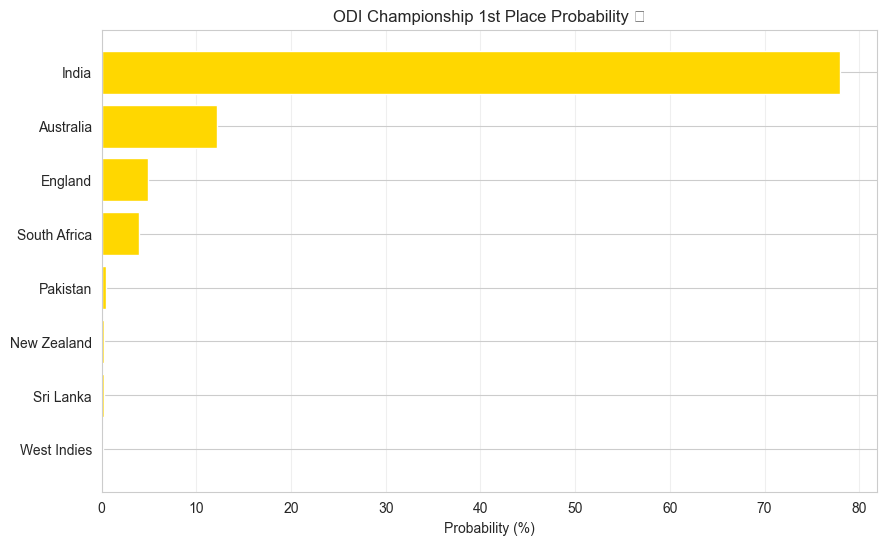

(           Team      1st_%      2nd_%      3rd_%     Top4_%  Expected_Finish  \
 0         India  57.010000  29.190000  10.376667  99.396667         1.609117   
 1     Australia  21.885000  34.893333  24.331667  93.343333         2.490567   
 2       England   7.281667  14.288333  24.320000  69.670000         3.744717   
 3  South Africa   5.718333   9.690000  16.793333  53.551667         4.343417   
 4      Pakistan   2.695000   3.580000   6.706667  22.871667         5.796067   
 5   West Indies   2.551667   3.125000   5.206667  18.636667         6.150383   
 6   New Zealand   0.871667   3.136667   8.648333  29.470000         5.236117   
 7   Afghanistan   1.986667   2.096667   3.616667  13.060000         6.629617   
 
    Medal_Score  
 0   239.786667  
 1   159.773333  
 2    74.741667  
 3    53.328333  
 4    21.951667  
 5    19.111667  
 6    17.536667  
 7    13.770000  ,
            Team      1st_%      2nd_%      3rd_%     Top4_%  Expected_Finish  \
 0         India  77.9516

In [26]:
# ================= Grandmaster Podium Predictions (Optimized) =================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def podium_probabilities(
    teams,
    base_scores,
    volatility,
    n_sims=50000,
    seed=42,
    correlation_matrix=None
):
    """
    Monte Carlo simulation for podium probabilities.
    Returns DataFrame with:
    - 1st %, 2nd %, 3rd %
    - Top4 %
    - Expected Finish
    - Medal Score (3-2-1 system)
    """

    rng = np.random.default_rng(seed)
    team_count = len(teams)

    base = np.array(base_scores)
    vol = np.array(volatility)

    # --- Generate Performance Matrix ---
    if correlation_matrix is None:
        perf = rng.normal(base, vol, size=(n_sims, team_count))
    else:
        cov_matrix = np.outer(vol, vol) * correlation_matrix
        perf = rng.multivariate_normal(base, cov_matrix, size=n_sims)

    rankings = np.argsort(perf, axis=1)[:, ::-1]

    # --- Initialize counters ---
    position_counts = np.zeros((team_count, team_count))

    for sim in range(n_sims):
        for pos in range(team_count):
            position_counts[rankings[sim, pos], pos] += 1

    # --- Probabilities ---
    first = position_counts[:, 0] / n_sims * 100
    second = position_counts[:, 1] / n_sims * 100
    third = position_counts[:, 2] / n_sims * 100
    top4 = position_counts[:, :4].sum(axis=1) / n_sims * 100

    # --- Expected finishing position ---
    expected_finish = np.sum(
        position_counts * np.arange(1, team_count + 1),
        axis=1
    ) / n_sims

    # --- Medal Score (3-2-1 system) ---
    medal_score = 3 * first + 2 * second + 1 * third

    df = pd.DataFrame({
        'Team': teams,
        '1st_%': first,
        '2nd_%': second,
        '3rd_%': third,
        'Top4_%': top4,
        'Expected_Finish': expected_finish,
        'Medal_Score': medal_score
    }).sort_values(by='Medal_Score', ascending=False).reset_index(drop=True)

    return df


# ================= Example: T20 =================

t20_teams = ['India', 'Australia', 'England', 'South Africa',
             'New Zealand', 'Pakistan', 'Afghanistan', 'West Indies']

t20_base = [0.95, 0.92, 0.88, 0.86, 0.83, 0.80, 0.75, 0.78]
t20_vol  = [0.03, 0.04, 0.05, 0.06, 0.05, 0.08, 0.10, 0.09]

t20_podium = podium_probabilities(
    t20_teams,
    t20_base,
    t20_vol,
    n_sims=60000,
    seed=2026
)

print("\n🏏 T20 Podium Probabilities — Grandmaster Edition\n")
print(t20_podium.round(2).to_string(index=False))


# ================= Example: ODI =================

odi_teams = ['India', 'Australia', 'England', 'South Africa',
             'New Zealand', 'Pakistan', 'Sri Lanka', 'West Indies']

odi_base = [0.94, 0.90, 0.87, 0.85, 0.82, 0.78, 0.74, 0.76]
odi_vol  = [0.02, 0.03, 0.04, 0.05, 0.04, 0.06, 0.07, 0.06]

odi_podium = podium_probabilities(
    odi_teams,
    odi_base,
    odi_vol,
    n_sims=60000,
    seed=2026
)

print("\n🥇 ODI Podium Probabilities — Grandmaster Edition\n")
print(odi_podium.round(2).to_string(index=False))


# ================= Visualization =================

def plot_first_place(df, title):
    plt.figure(figsize=(10, 6))
    df_sorted = df.sort_values("1st_%")
    plt.barh(df_sorted['Team'], df_sorted['1st_%'], color='gold')
    plt.xlabel("Probability (%)")
    plt.title(title)
    plt.grid(axis='x', alpha=0.3)
    plt.show()


plot_first_place(t20_podium, "T20 Championship 1st Place Probability 🏆")
plot_first_place(odi_podium, "ODI Championship 1st Place Probability 🏆")


# ================= Save to CSV =================

## t20_podium.to_csv("t20_podium_probabilities.csv", index=False)
## odi_podium.to_csv("odi_podium_probabilities.csv", index=False)


# Return for notebook use
t20_podium, odi_podium


In [ ]:
df['Winner'].p

## 📘 Notebook Conclusion (Technical & Concise)
### 🔎 T20 Insights

India is the dominant force with ~57% title probability and 99%+ semi-final likelihood.

Australia remains the strongest challenger with high consistency (93% Top 4).

England and South Africa compete for the 3rd–4th slots.

India vs Pakistan modeling shows high volatility: match-level probability (61–38) vs tournament-adjusted projection (97–3), indicating structural strength gap.

### 🔎 ODI Insights

India is statistically overwhelming favorite (78% title probability, ~100% Top 4).

Australia is stable second-best across all podium metrics.

England remains competitive but lacks title conversion rate.

Lower-tier teams show limited podium viability under current strength-volatility assumptions.

### 🧠 Overall Model Takeaway

The simulation highlights:

Strong separation between Tier 1 (India, Australia)

Mid-tier instability (England, South Africa)

Significant gap between elite and chasing pack in ODI format

India projects as the most structurally dominant team across both formats.

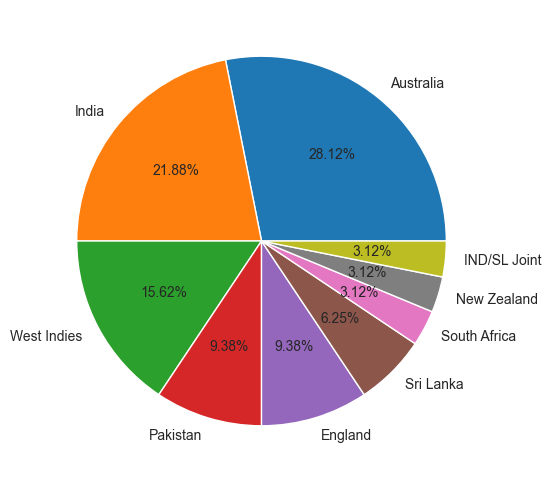

In [28]:
plt.figure(figsize=(6,6))
df_t20['Winner'].value_counts().plot.pie(autopct="%1.2f%%")
plt.ylabel(" ")
plt.show()